In [9]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.plot import show

In [10]:
# ==========================================================
# FILE PATHS
# ==========================================================

DATA = Path("/home/jovyan/Society_of_Bouy_Cowboys/Data")

NETCDF = DATA / "NET_CDF"
ICE = DATA / "Ice_edge"
SAT = DATA / "SAT_GeoTiff"

raster_file = SAT / "IcyCape_201911201739_S1B_EW_50m.tif"
edge_file = ICE / "ice_edge_11201739.geojson"


# buoy files
moor_files = {
    "S1P1": NETCDF / "S1P1.nc",
    "S1P2": NETCDF / "S1P2.nc",
    "S1P3": NETCDF / "S1P3.nc",
    "S1A1": NETCDF / "S1A1.nc"
}


# CRS used for ALL spatial analysis
analysis_crs = "EPSG:32604"

In [11]:
# ==========================================================
# HELPER FUNCTION
# Extract representative lat/lon for each buoy
# ==========================================================

def get_mooring_latlon(ncfile):
    ds = xr.open_dataset(ncfile)

    lat = np.asarray(ds["lat_lagrangian"]).astype(float).ravel()
    lon = np.asarray(ds["lon_lagrangian"]).astype(float).ravel()

    good = np.isfinite(lat) & np.isfinite(lon)

    lat = lat[good]
    lon = lon[good]

    if len(lat) == 0:
        raise ValueError(f"No valid lat/lon found in {ncfile}")

    # median gives robust representative location
    return np.median(lat), np.median(lon)

In [12]:
# ==========================================================
# BUILD BUOY TABLE
# ==========================================================
rows = []

for name, fn in moor_files.items():
    lat, lon = get_mooring_latlon(fn)
    rows.append({
        "source": name,
        "lat": lat,
        "lon": lon
    })

moor_df = pd.DataFrame(rows)

In [13]:
# ==========================================================
# BUOY GEO DATAFRAME
# ==========================================================

moor_gdf = gpd.GeoDataFrame(
    moor_df,
    geometry=gpd.points_from_xy(moor_df["lon"], moor_df["lat"]),
    crs="EPSG:4326"
)

# convert buoys into analysis CRS
moor_gdf = moor_gdf.to_crs("EPSG:32604")


print("Buoys in analysis CRS:")
print(moor_gdf[["source","geometry"]])

Buoys in analysis CRS:
  source                        geometry
0   S1P1  POINT (385288.486 7807356.201)
1   S1P2   POINT (382579.19 7812922.163)
2   S1P3  POINT (380366.746 7818088.385)
3   S1A1  POINT (377672.411 7823482.253)


In [21]:
def utm_fwd(lon_deg, lat_deg, zone=4):
    """WGS84 lon/lat (degrees) -> UTM Zone 4N easting/northing (metres)."""
    a   = 6378137.0           # WGS84 semi-major axis
    f   = 1 / 298.257223563   # WGS84 flattening
    e2  = 2*f - f**2
    ep2 = e2 / (1 - e2)
    k0  = 0.9996              # UTM scale factor
    E0  = 500000.0            # false easting

    lam0 = np.radians(-180 + (zone - 1)*6 + 3)   # central meridian = -159

    phi = np.radians(lat_deg)
    lam = np.radians(lon_deg)

    N  = a / np.sqrt(1 - e2 * np.sin(phi)**2)
    T  = np.tan(phi)**2
    C  = ep2 * np.cos(phi)**2
    A_ = np.cos(phi) * (lam - lam0)

    e4 = e2**2;  e6 = e2**3
    M  = a * ((1 - e2/4 - 3*e4/64 - 5*e6/256)   * phi
              - (3*e2/8 + 3*e4/32 + 45*e6/1024)  * np.sin(2*phi)
              + (15*e4/256 + 45*e6/1024)          * np.sin(4*phi)
              - (35*e6/3072)                       * np.sin(6*phi))

    x = k0*N*(A_ + (1 - T + C)*A_**3/6
              + (5 - 18*T + T**2 + 72*C - 58*ep2)*A_**5/120) + E0
    y = k0*(M + N*np.tan(phi)*(A_**2/2
              + (5 - T + 9*C + 4*C**2)*A_**4/24
              + (61 - 58*T + T**2 + 600*C - 330*ep2)*A_**6/720))
    return x, y

In [22]:
# Convert lat/lon to EPSG:32604 using utm_fwd from the script
xs, ys = utm_fwd(moor_df["lon"].values, moor_df["lat"].values)

# Build GeoDataFrame in EPSG:32604
moor_32604 = gpd.GeoDataFrame(
    moor_df,
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs="EPSG:32604"
)

print(moor_32604[["source", "geometry"]])

  source                        geometry
0   S1P1  POINT (385288.486 7807356.202)
1   S1P2   POINT (382579.19 7812922.164)
2   S1P3  POINT (380366.746 7818088.386)
3   S1A1  POINT (377672.412 7823482.254)


In [26]:
print(moor_df[["lat", "lon"]].head())

# Also print the raster bounds to compare
import rasterio
with rasterio.open(raster_file) as src:
    print("Raster bounds:", src.bounds)

# And print the converted points
print(moor_32604.geometry)

        lat        lon
0  70.34613 -162.05704
1  70.39473 -162.13675
2  70.43995 -162.20300
3  70.48695 -162.28278
Raster bounds: BoundingBox(left=0.0, bottom=-148074.0, right=202101.0, top=0.0)
0    POINT (385288.486 7807356.202)
1     POINT (382579.19 7812922.164)
2    POINT (380366.746 7818088.386)
3    POINT (377672.412 7823482.254)
Name: geometry, dtype: geometry


In [23]:
# ==========================================================
# LOAD ICE EDGE
# ==========================================================
edge_gdf = gpd.read_file(edge_file)

print("Edge CRS from file:", edge_gdf.crs)
print("Edge bounds:", edge_gdf.total_bounds)

with rasterio.open(raster_file) as src:
    print("raster bounds:", src.bounds)
    print("raster CRS:", src.crs)

Edge CRS from file: EPSG:32604
Edge bounds: [   4586.15203503 -140207.18467934  200032.39801059  -57337.97638571]
raster bounds: BoundingBox(left=0.0, bottom=-148074.0, right=202101.0, top=0.0)
raster CRS: None


In [15]:
#fig, ax = plt.subplots(figsize=(10, 8))

#with rasterio.open(raster_file) as src:
    #show(src, ax=ax, cmap="gray")

#edge_gdf.plot(ax=ax, color="cyan", linewidth=2)

#ax.set_title("Click control points, then press Enter")
#scene_pts = plt.ginput(n=-1, timeout=0)
#plt.show()

#scene_pts = np.array(scene_pts)
#scene_pts

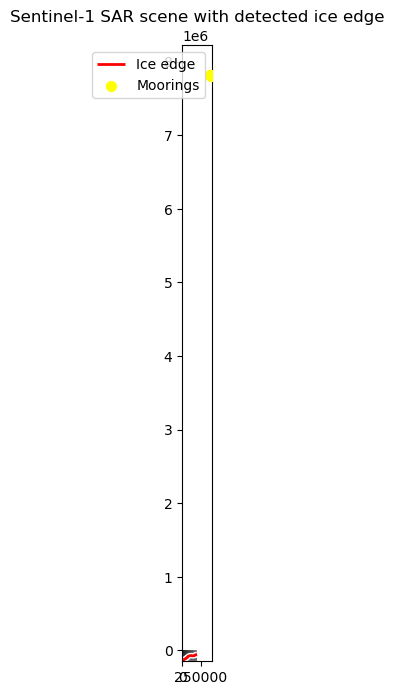

In [25]:
# ==========================================================
# PLOT RASTER + ICE EDGE
# ==========================================================

fig, ax = plt.subplots(figsize=(10,8))

with rasterio.open(raster_file) as src:

   # print("Raster bounds:", src.bounds)
   # print("Raster CRS:", src.crs)

    show(src, ax=ax, cmap="gray")


# edge already matches raster coordinate system
edge_gdf.plot(
    ax=ax,
    color="white",
    linewidth=4
)

edge_gdf.plot(
    ax=ax,
    color="red",
    linewidth=2,
    label="Ice edge"
)


moor_32604.plot(ax=ax, color="yellow", markersize=50, zorder=5, label="Moorings")

ax.set_title("Sentinel-1 SAR scene with detected ice edge")

ax.legend()

In [17]:
aux_file = DATA / "SAT_GeoTiff/IcyCape_201911201739_S1B_EW_50m.tif.aux.xml"

with open(aux_file, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(text[:5000])

<PAMDataset>
  <PAMRasterBand band="1">
    <Histograms>
      <HistItem>
        <HistMin>0.0009196509052657617</HistMin>
        <HistMax>0.01391557323237573</HistMax>
        <BucketCount>249320</BucketCount>
        <IncludeOutOfRange>0</IncludeOutOfRange>
        <Approximate>1</Approximate>
        <HistCounts>1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|

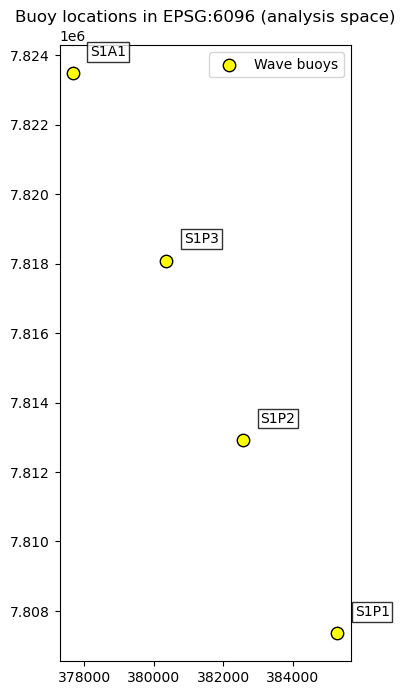

In [19]:
# ==========================================================
# OPTIONAL: PLOT BUOYS + ICE EDGE IN ANALYSIS SPACE
# ==========================================================

# This figure is for geometry calculations,
# not raster overlay.

edge_6096 = None

try:
    edge_6096 = edge_gdf.to_crs(analysis_crs)
except:
    print("Edge cannot be converted to analysis CRS (scene coords).")


fig, ax = plt.subplots(figsize=(8,8))

moor_gdf.plot(
    ax=ax,
    color="yellow",
    edgecolor="black",
    markersize=80,
    label="Wave buoys"
)

for x, y, label in zip(
    moor_gdf.geometry.x,
    moor_gdf.geometry.y,
    moor_gdf["source"]
):

    ax.text(
        x + 500,
        y + 500,
        label,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, pad=2)
    )


ax.set_title("Buoy locations in EPSG:6096 (analysis space)")

ax.set_aspect("equal")

ax.legend()